In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random, os
from datetime import datetime

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("device →", device)

from hcg.interpolant import MLPInstFlexible, run_training_v_s
from hcg.sample_data import sample_checkerboard, make_conditions, sample_data_model1, sample_data_model2, sample_data_model3, ground_truth_hcg, plot_diagnostics
from hcg.hcg import simulate_hcg, simulate_hcg_generalized

### Run this ONCE per experiment
new_experiment = False  # Set to False to reuse an old experiment ID
if new_experiment:  # Run the experiment with the current date and time as the experiment ID
    experiment_id = f"experiment_{datetime.now().strftime('%Y%m%d')}" #_%H%M%S
    os.makedirs(experiment_id, exist_ok=True)
else:
    experiment_id = "experiment_20250830"  # Use a fixed ID for reproducibility

bs = 5000

device → cuda


# Toy Distributions

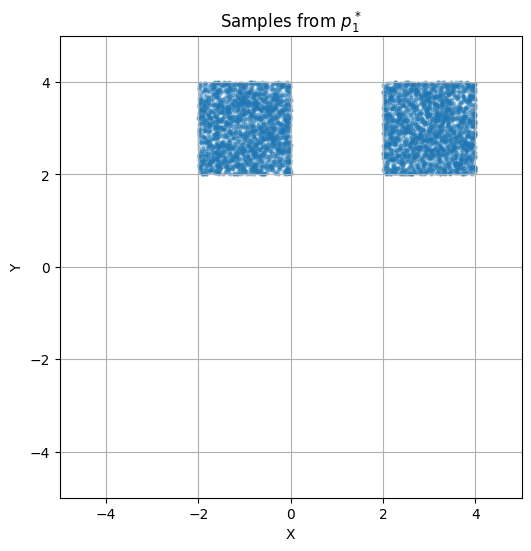

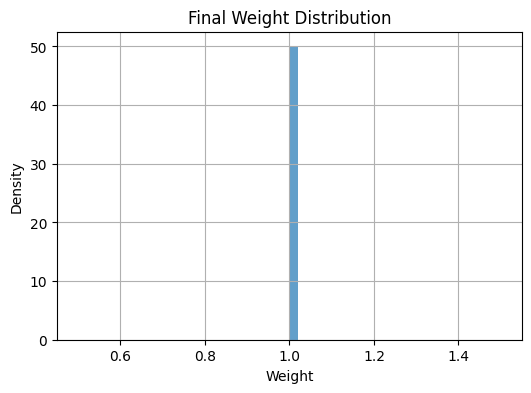

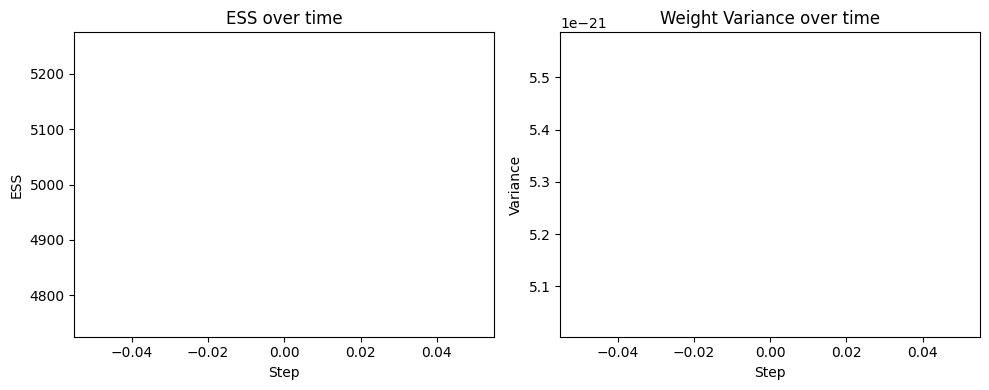

In [2]:
# plot ground truth
samples_gt = ground_truth_hcg(bs, cond_A=1, cond_B=1).cpu().numpy()
plot_diagnostics(samples_gt, torch.zeros(bs), [torch.zeros(bs)], save_name=f"{experiment_id}/ground_truth")

# With Pretrained Models

In [33]:
# Load all the models
u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{experiment_id}/u_model1_X_given_A.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{experiment_id}/s_model1_X_given_A.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{experiment_id}/u_model2_XY_given_B.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{experiment_id}/s_model2_XY_given_B.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{experiment_id}/u_model3_X.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{experiment_id}/s_model3_X.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
def sigma_fn(t): return 1.0 * torch.ones_like(t)
print("Models loaded.")

Models loaded.


/tmp/ipykernel_2029843/3695170050.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(de

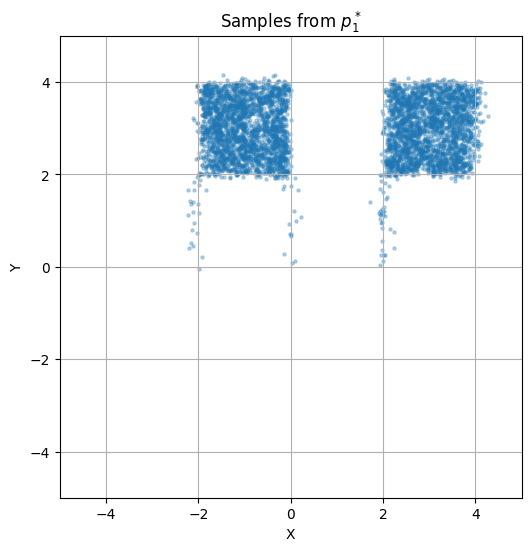

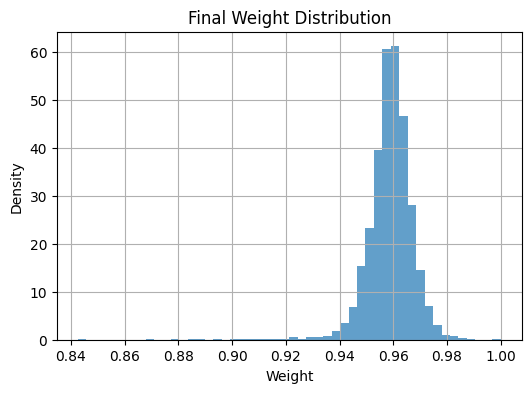

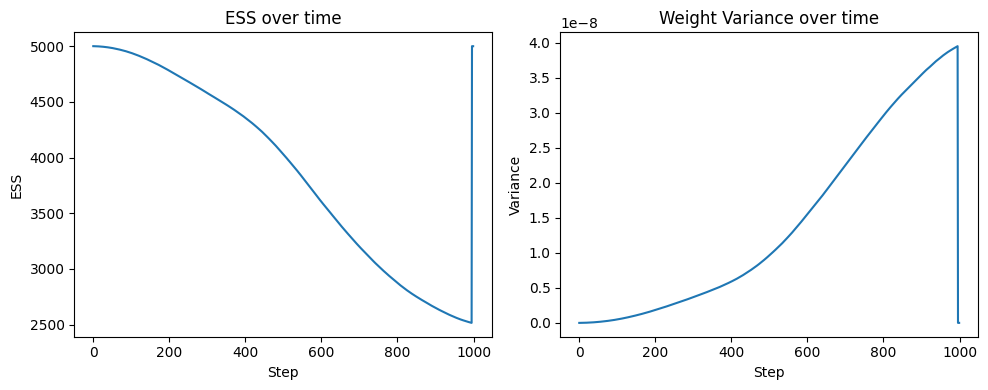

In [4]:
x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 1, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[1, -1, 1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z[:, :1],    # project to X
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    inv_proj_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    #lambda z, t: torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1), # v_star = v1
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/tmp")

if False: # equivalent, less general function call
    z0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
    A, B = 1, 1  # Conditioning values

    samples, logw_final, logw_history, sample_history = simulate_hcg(
        z0,     v1_fn, s1_fn,     v2_fn, s2_fn,     v3_fn, s3_fn,     sigma_fn,     A=A, B=B,  # Conditioning values
        t0=0.0, t1=1.0, n_steps=1000, device="cuda", resample=True, perturb=False, ess_threshold=0.5, v_star_type="v1"
    )
    samples = samples.cpu().numpy()
    plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/tmp")

# FKC Baseline - Homogenized Distributions + FKC

### Define homogenized $q^{(1)}$ and $q^{(2)}$.

Extend each 1D density in $X$ to a 2D one by multiplying with a simple factor in $Y$:

$$
q^{(1)}(x,y \mid A) = q^{(1)}(x \mid A) \cdot f(y),
$$

$$
q^{(2)}(x,y) = q^{(2)}(x)\cdot f(y),
$$

where $f(y)$ is a Gaussian $ \mathcal{N}(0,1)$ or uniform on $[-M,M]$.

Then their score functions decompose:

* For $q^{(1)}$:

$$
s^{(1)}(x,y) = \Big(\,\nabla_x \log q^{(1)}(x \mid A), \;\nabla_y \log f(y)\,\Big),
$$

* For $q^{(2)}$:

$$
s^{(2)}(x,y) = \Big(\,\nabla_x \log q^{(2)}(x), \;\nabla_y \log f(y)\,\Big),
$$

* For $q^{(3)}$ (already 2D): $s^{(3)}(x,y)$ as usual.

So you just need to implement `f(y)` and its score.

### Choosing $f(y)$

* If **Gaussian $f(y)\sim\mathcal{N}(0,1)$**: score is just `-y`.
* If **Uniform on \[-M,M]**: score is `0` inside, but undefined at boundary → you’d need to enforce absorbing or reflecting boundaries in simulation. Much easier to stick with Gaussian unless you want hard support constraints.

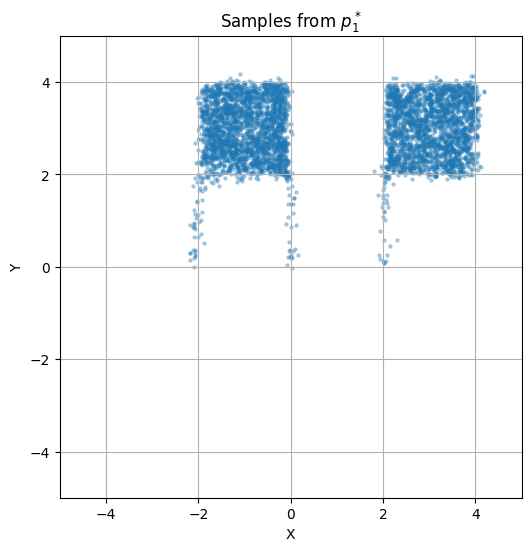

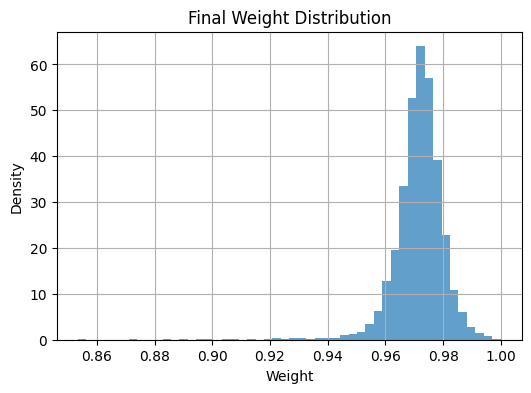

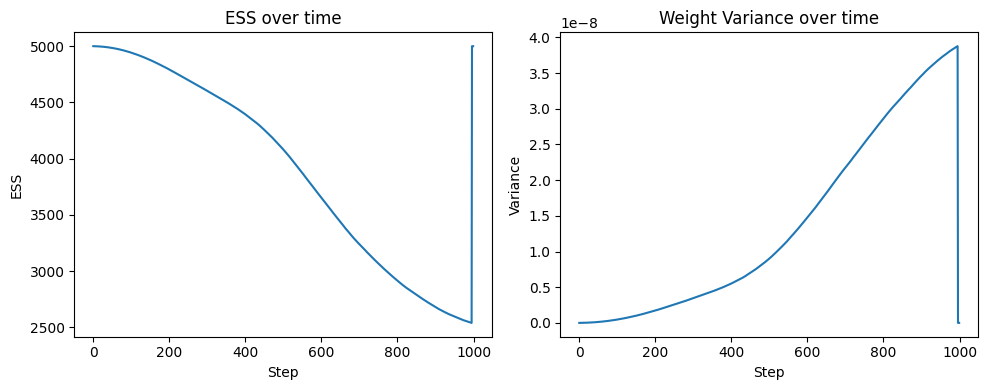

In [5]:
x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values
# choose f(y) = N(0, 1)  => score s_f(y) = -y
def s_fp(y):           # y has shape (bs,1)
    return -y
def s_fn(y):           # y has shape (bs,1)
    return -y # -0.5*y
def v_fp(y, t):        # choose zero deterministic drift in y
    return torch.zeros_like(y)
def v_fn(y, t):        # choose zero deterministic drift in y
    return torch.zeros_like(y)

# build v_fn_list and s_fn_list that return 2D vectors for (x,y)
v_fn_list = [
    lambda z, t: torch.cat([ v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), v_fp(z[:, 1:2], t) ], dim=1),
    lambda z, t: torch.cat([ v2_fn(z[:, :1], t),            v_fn(z[:, 1:2], t) ], dim=1),
    lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))   # already 2D
]
s_fn_list = [
    lambda z, t: torch.cat([ s1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), s_fp(z[:, 1:2]) ], dim=1),
    lambda z, t: torch.cat([ s2_fn(z[:, :1], t),            s_fn(z[:, 1:2]) ], dim=1),
    lambda z, t: s3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))   # already 2D
]
# pass identity projections since all are now 2D
proj_list = [lambda z: z, lambda z: z, lambda z: z]
inv_proj_list = [lambda z: z, lambda z: z, lambda z: z]
# v_star: extend original v1 in x and zero in y
v_star = lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))
#lambda z, t: torch.cat([ v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device) ], dim=1)


samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[2, 2, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=v_fn_list,
    s_fn_list=s_fn_list,
    gamma_list=[1, -1, 1],     # from log-weight increment in simulate_hcg
    proj_list=proj_list,
    inv_proj_list=inv_proj_list,
    sigma_fn=sigma_fn,
    v_star=v_star,
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/fkc-1")

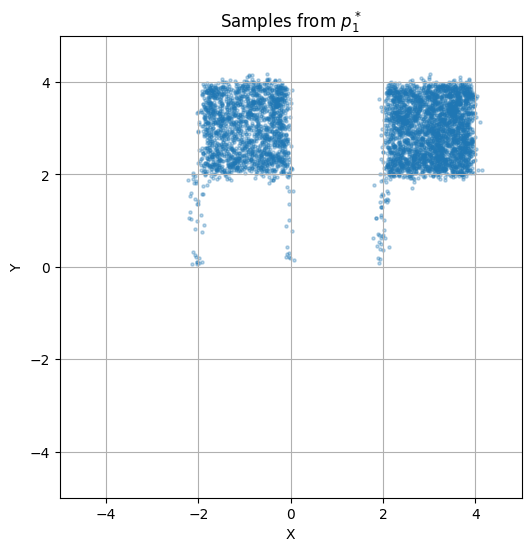

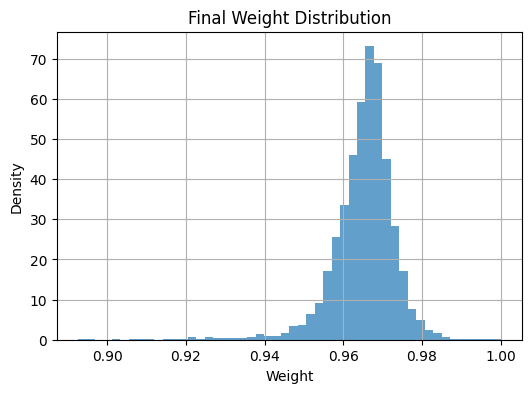

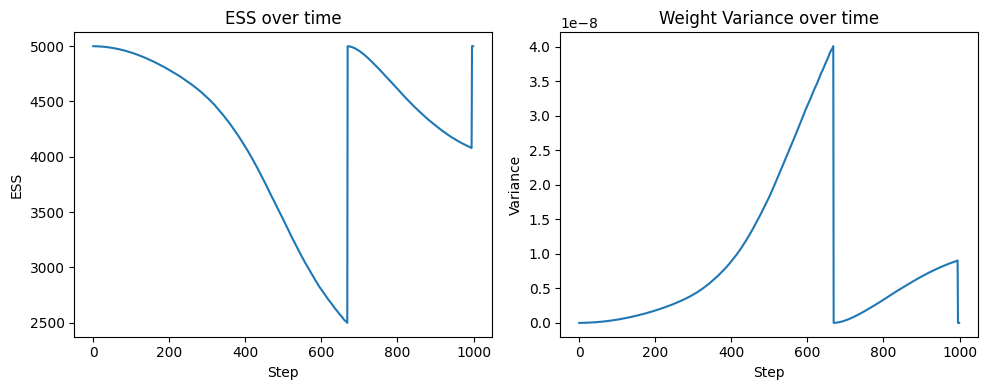

In [6]:
# Product of Experts

x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[1, 1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    inv_proj_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    #lambda z, t: torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1), # v_star = v1
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/tmp")

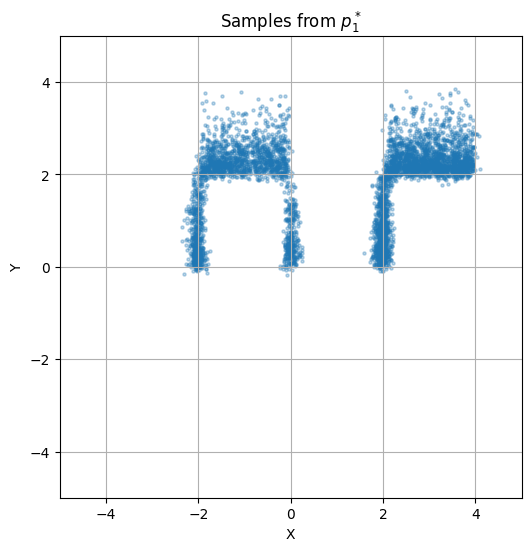

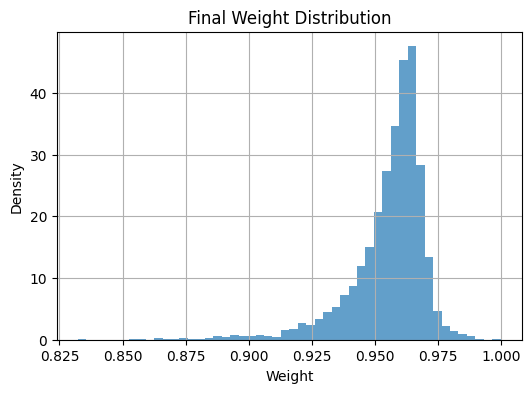

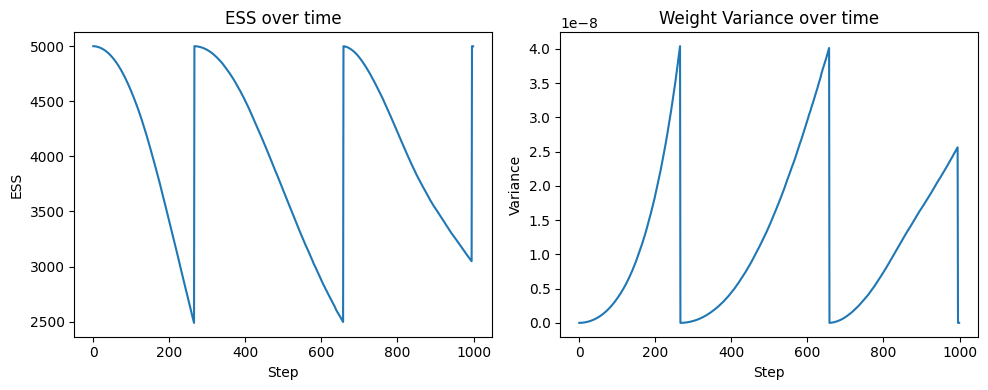

In [7]:
x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

# choose f(y) = N(0, 1)  => score s_f(y) = -y
def s_f(y):           # y has shape (bs,1)
    return -y
def v_f(y, t):        # choose zero deterministic drift in y
    return torch.zeros_like(y)

v_fn_list = [
    lambda z, t: torch.cat([ v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), v_f(z[:, 1:2], t) ], dim=1),
    lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))   # already 2D
]
s_fn_list = [
    lambda z, t: torch.cat([ s1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), s_f(z[:, 1:2]) ], dim=1),
    lambda z, t: s3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))   # already 2D
]
proj_list = [lambda z: z, lambda z: z]
inv_proj_list = [lambda z: z, lambda z: z]
v_star = lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device))


samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[2, 2],
    v_fn_list=v_fn_list,
    s_fn_list=s_fn_list,
    gamma_list=[1, 1],     # from log-weight increment in simulate_hcg
    proj_list=proj_list,
    inv_proj_list=inv_proj_list,
    sigma_fn=sigma_fn,
    v_star=v_star,
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/fkc-1")

# Evaluation with Metrics

Following the FKC paper, we sample 10k samples with 1000 sampling steps.

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics

torch.set_num_threads(16)  # adjust for your CPU


bs = 5000  # batch size
seeds = [0] #[1, 2]
v_star_types = ["v1"] #["v1", "v2", "v3", "v1+v2+v3"]
ess_thresholds = [0.5] #[0.1, 0.5, 0.9]
all_results = []
os.makedirs(f"{experiment_id}/plot_diagnostics", exist_ok=True)

for seed in seeds:
    gtvsgt = True # Run once per seed
    for v_star_type in v_star_types:
        for ess_threshold in ess_thresholds:
            print(f"Running seed {seed} with v_star_type {v_star_type} and ess_threshold {ess_threshold}...")

            ### RUN EXPERIMENT
            torch.manual_seed(seed)
            np.random.seed(seed)

            z0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
            A, B = 1, 1

            # Simulations
            methods = {}
            methods["Baseline"], logw_final, logw_history, _ = simulate_hcg(
                z0, v1_fn, s1_fn, v2_fn, s2_fn, v3_fn, s3_fn, sigma_fn,
                A=A, B=B, t0=0.0, t1=1.0, n_steps=1000,
                device="cuda", resample=False, perturb=False, ess_threshold=ess_threshold, v_star_type=v_star_type
            )
            plot_diagnostics(methods["Baseline"].cpu().numpy(), logw_final, logw_history, save_name=f"{experiment_id}/plot_diagnostics/seed{seed}_ess_{ess_threshold}_v_star_{v_star_type}_heuristic")
            
            methods["HCG"], logw_final, logw_history, _ = simulate_hcg(
                z0, v1_fn, s1_fn, v2_fn, s2_fn, v3_fn, s3_fn, sigma_fn,
                A=A, B=B, t0=0.0, t1=1.0, n_steps=1000,
                device="cuda", resample=True, perturb=False, ess_threshold=ess_threshold, v_star_type=v_star_type
            )
            plot_diagnostics(methods["HCG"].cpu().numpy(), logw_final, logw_history, save_name=f"{experiment_id}/plot_diagnostics/seed{seed}_ess_{ess_threshold}_v_star_{v_star_type}_hcg")

            # Convert to numpy
            methods = {k: v.cpu().numpy() for k, v in methods.items()}

            # Metrics
            results = []
            samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
            for method_name, samples in methods.items():
                w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
                    torch.tensor(samples_gt), torch.tensor(samples)
                )
                results.append([seed, v_star_type, ess_threshold, method_name, w1, w2, mmd_rbf, total_var])

            # GT vs GT sanity check
            # Ground truth
            if gtvsgt:
                gtvsgt = False # Only run once per seed
                samples_gt_ref = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
                w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
                    torch.tensor(samples_gt), torch.tensor(samples_gt_ref)
                )
                results.append([seed, v_star_type, ess_threshold, "GTvsGT", w1, w2, mmd_rbf, total_var])

            ### COLLECT RESULTS
            all_results.extend(results)  

df = pd.DataFrame(all_results, columns=["seed", "v_star_type", "ess", "method", "W1", "W2", "MMD_RBF", "Total Var."])
df.to_csv(f"{experiment_id}/experiment_results_numseeds{len(seeds)}_bs{bs}.csv", index=False)
print(df)

# Training Script

In [ ]:
if False:
    # Training takes ~2min on a single GPU
    u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device) # X | A
    s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device) # X | A
    run_training_v_s(u_model1, s_model1, sample_data_model1, plot_cond_val=1.0, n_iters=2000)
    # save the models
    torch.save(u_model1.state_dict(), f"{experiment_id}/u_model1_X_given_A.pth")
    torch.save(s_model1.state_dict(), f"{experiment_id}/s_model1_X_given_A.pth")
    
if False:
    # Training takes ~8 minutes on a GPU
    u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1) # X
    s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1) # X
    run_training_v_s(u_model3, s_model3, sample_data_model3, n_iters=2000)
    # save the models
    torch.save(u_model3.state_dict(), f"{experiment_id}/u_model3_X.pth")
    torch.save(s_model3.state_dict(), f"{experiment_id}/s_model3_X.pth")
    
if False:
    # Training takes ~10 minutes on a GPU
    u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2) # X, Y | B
    s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2) # X, Y | B
    run_training_v_s(u_model2, s_model2, sample_data_model2, plot_cond_val=1.0, n_iters=5000)
    # save the models
    torch.save(u_model2.state_dict(), f"{experiment_id}/u_model2_XY_given_B.pth")
    torch.save(s_model2.state_dict(), f"{experiment_id}/s_model2_XY_given_B.pth")

# Ratio of Experts $q^1/q^2$

In [ ]:
def sample_data_q1(bs, cond=None, id=0):
    """
    Samples from q^1(x): N(-2, 0.5^2)
    `cond` is a dummy argument for compatibility (e.g., A)
    """
    if id == 0:
        return torch.randn(bs, 1, device=device) + (-2.0), None
    elif id == 1:
        mix = torch.bernoulli(0.9 * torch.ones(bs, 1, device=device))
        left = torch.randn(bs, 1, device=device) + (-2.0)
        right = torch.randn(bs, 1, device=device) + (2.0)
        return mix * right + (1 - mix) * left, None

def sample_data_q2(bs, cond=None, id=0):
    """
    Samples from q^2(x): 50% N(-2, 0.5^2) + 50% N(2, 0.5^2)
    `cond` is a dummy argument for compatibility
    """
    if id == 0:
        mix = torch.bernoulli(0.5 * torch.ones(bs, 1, device=device))
        left = torch.randn(bs, 1, device=device) + (-2.0)
        right = torch.randn(bs, 1, device=device) + (2.0)
        return mix * right + (1 - mix) * left, None

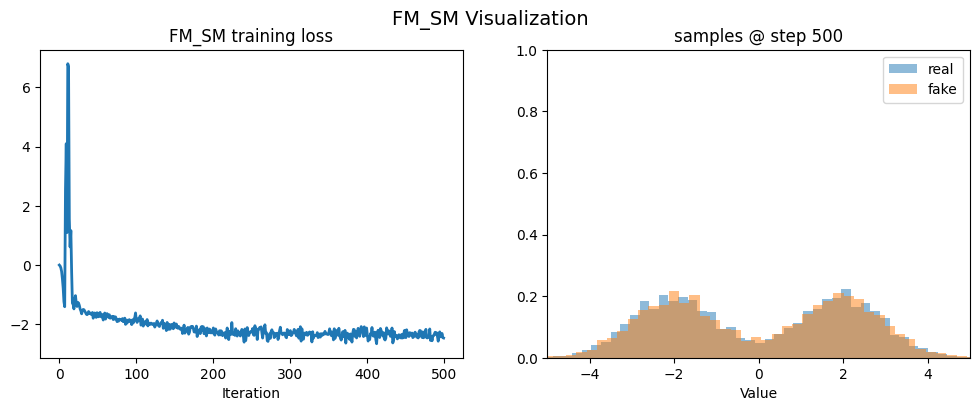

In [27]:
if True:
    # Training takes ~6s on a single GPU
    u_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    s_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    run_training_v_s(u_q1, s_q1, sample_data_q1, plot_cond_val=None, n_iters=500)
    # save the models
    torch.save(u_q1.state_dict(), f"{experiment_id}/ratio_u_q1.pth")
    torch.save(s_q1.state_dict(), f"{experiment_id}/ratio_s_q1.pth")
if True:
    # Training takes ~5s on a single GPU
    u_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    s_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    run_training_v_s(u_q2, s_q2, sample_data_q2, plot_cond_val=None, n_iters=500)
    # save the models
    torch.save(u_q2.state_dict(), f"{experiment_id}/ratio_u_q2.pth")
    torch.save(s_q2.state_dict(), f"{experiment_id}/ratio_s_q2.pth")

In [28]:
# q1 / q2 where q1 is a guassian centered at -2 and q2 is a guassian centered at 2 and -2

# Load the saved models
u_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
s_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
u_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
s_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
u_q1.load_state_dict(torch.load(f"{experiment_id}/ratio_u_q1.pth"))
s_q1.load_state_dict(torch.load(f"{experiment_id}/ratio_s_q1.pth"))
u_q2.load_state_dict(torch.load(f"{experiment_id}/ratio_u_q2.pth"))
s_q2.load_state_dict(torch.load(f"{experiment_id}/ratio_s_q2.pth"))

# v1: for q^1 (N(-2))
def v1_fn(x, t): return u_q1(x, t)
def s1_fn(x, t): return s_q1(x, t)

# v2: for q^2 (mixture of N(-2), N(+2))
def v2_fn(x, t): return u_q2(x, t)
def s2_fn(x, t): return s_q2(x, t)

# Constant diffusion coefficient
def sigma_fn(t): return torch.ones_like(t)


/tmp/ipykernel_2029843/4289259188.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  u_q1.load_state_dict(torch.load(f"{experiment_id}/ratio_u_q1.pth"))
/tmp/ipykernel_2029

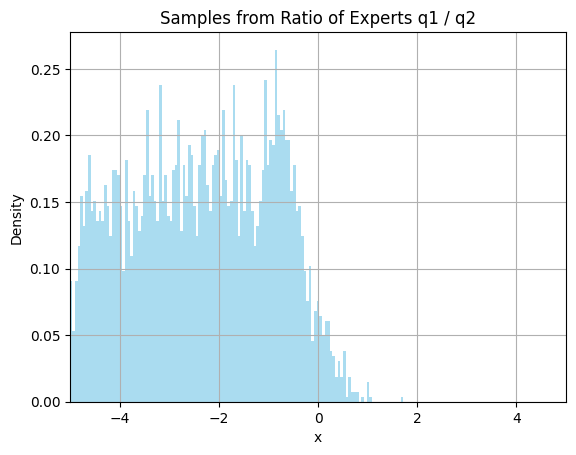

In [29]:
# Uniform Sample
x0 = torch.rand(bs, 1).to(device) * 10 - 5

samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 1], 
    v_fn_list=[
        lambda x, t: v1_fn(x, t),                                                 # v1(X)
        lambda x, t: v2_fn(x, t),                                                 # v2(X)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x, t),                                                 # s1(X)
        lambda x, t: s2_fn(x, t),                                                 # s2(X)
    ],
    gamma_list=[1, -1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z, 
        lambda z: z 
    ],
    inv_proj_list=[
        lambda z: z,  # identity
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    v_star= lambda z, t: v2_fn(z, t), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plt.hist(samples, bins=200, density=True, alpha=0.7, color="skyblue")
plt.title("Samples from Ratio of Experts q1 / q2")
plt.grid(True)
plt.xlabel("x"); plt.xlim(-5,5)
plt.ylabel("Density")
plt.show()